# RITMO Pipeline - Validación Completa

**Estados Ocultos como Embeddings Estructurados**

Pipeline:
1. RevIN → Normalización reversible
2. Baum-Welch → Entrenamiento HMM (K=5 tokens)
3. Viterbi → Tokenización
4. Embeddings → e_k = [μ_k, σ_k, A[k,:]]

In [1]:
import os
import sys
from pathlib import Path

# Cambiar al directorio raíz del proyecto
if Path.cwd().name == 'notebooks':
    os.chdir('..')

print(f'Working directory: {Path.cwd()}')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Módulos RITMO
from utils.revin import RevINNormalizer
from hmm import baum_welch, viterbi_decode, save_hmm_params, load_hmm_params
from embeddings import EmbeddingGenerator

# Configuración matplotlib (paper-ready)
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Okabe-Ito palette (colorblind-friendly)
colors_oi = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']

print('Setup completo')

Working directory: /home/jaime/TFG/RITMO
Setup completo


## 1. Carga ETTh1

In [2]:
df = pd.read_csv('dataset/ETT-small/ETTh1.csv')
data = df['OT'].values

# Split 8640/2880/2880
data_train = data[:8640]
data_val = data[8640:8640+2880]
data_test = data[8640+2880:]

print('[ETTh1 DATASET]')
print(f'  Train: {len(data_train)} samples')
print(f'  Val:   {len(data_val)} samples')
print(f'  Test:  {len(data_test)} samples')

[ETTh1 DATASET]
  Train: 8640 samples
  Val:   2880 samples
  Test:  5900 samples


## 2. RevIN Normalización

[REVIN NORMALIZACIÓN]
  Pre:  μ=17.128, σ=9.176
  Post: μ=-0.000000, σ=1.000000
  Reversibilidad: MSE=1.07e-13, Success=True


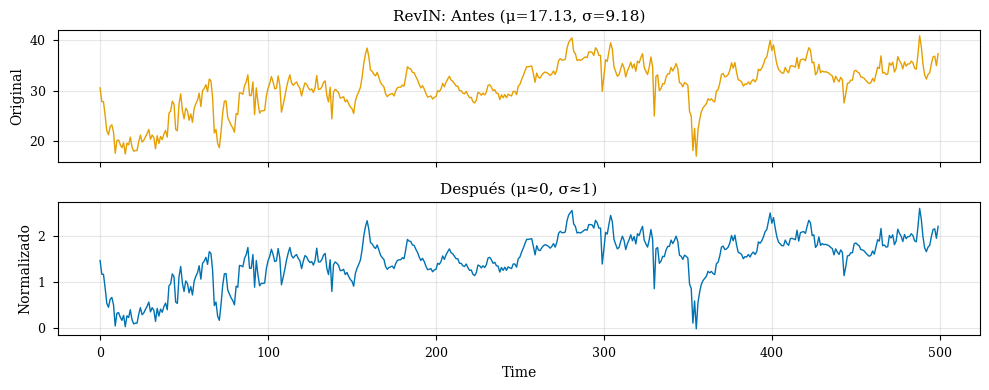


[GUARDADO] fase1_revin.pdf + .png


In [3]:
revin = RevINNormalizer()
normalized_data = revin.fit_transform(data_train)
data_train_norm = normalized_data['train']
stats = revin.get_statistics('train')

print('[REVIN NORMALIZACIÓN]')
print(f'  Pre:  μ={data_train.mean():.3f}, σ={data_train.std():.3f}')
print(f'  Post: μ={data_train_norm.mean():.6f}, σ={data_train_norm.std():.6f}')

success, mse = revin.validate_reconstruction(data_train, data_train_norm, 'train')
print(f'  Reversibilidad: MSE={mse:.2e}, Success={success}')

# VIZ: Antes/Después
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
t_viz = 500

ax1.plot(data_train[:t_viz], color=colors_oi[0], linewidth=1)
ax1.set_ylabel('Original')
ax1.set_title(f'RevIN: Antes (μ={stats["mean"]:.2f}, σ={stats["stdev"]:.2f})')
ax1.grid(alpha=0.3)

ax2.plot(data_train_norm[:t_viz], color=colors_oi[4], linewidth=1)
ax2.set_ylabel('Normalizado')
ax2.set_xlabel('Time')
ax2.set_title('Después (μ≈0, σ≈1)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('notebooks/fase1_revin.pdf')
plt.savefig('notebooks/fase1_revin.png', dpi=300)
plt.show()
print('\n[GUARDADO] fase1_revin.pdf + .png')

## 3. Baum-Welch Training

In [4]:
K = 5
cache_path = Path('cache/hmm_etth1_K5.pth')
cache_path.parent.mkdir(exist_ok=True)

print('[BAUM-WELCH TRAINING]')
print(f'  K={K} tokens (vocabulario)')
print(f'  T={len(data_train_norm)} timesteps')

if cache_path.exists():
    print(f'  Cargando HMM desde cache...')
    hmm_params = load_hmm_params(str(cache_path))
    A = hmm_params['A']
    pi = hmm_params['pi']
    mu = hmm_params['mu']
    sigma = hmm_params['sigma']
    log_likelihoods = hmm_params.get('log_likelihoods', [])
    print(f'  ✓ HMM cargado desde cache')
else:
    print(f'  Entrenando HMM desde cero (max_iter=200)...')
    result = baum_welch(
        data_train_norm,
        K=K,
        max_iter=500,
        epsilon=1e-4,
        verbose=True
    )
    
    A = result['A']
    pi = result['pi']
    mu = result['mu']
    sigma = result['sigma']
    log_likelihoods = result.get('log_likelihoods', [])
    
    print(f'\n  Convergió: {result["converged"]}')
    print(f'  Iteraciones: {result["n_iter"]}')
    print(f'  Log-likelihood: {result["log_likelihood"]:.2f}')
    
    # Guardar en cache
    save_params = {
        'A': A, 'pi': pi, 'mu': mu, 'sigma': sigma,
        'log_likelihoods': log_likelihoods,
        'K': K
    }
    save_hmm_params(save_params, str(cache_path))
    print(f'  ✓ HMM guardado en {cache_path}')

# VIZ: Convergencia
if len(log_likelihoods) > 0:
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(log_likelihoods, color=colors_oi[4], linewidth=1.5)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Log-likelihood')
    ax.set_title(f'Baum-Welch Convergence (K={K} tokens)')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('notebooks/fase2_baum_welch.pdf')
    plt.savefig('notebooks/fase2_baum_welch.png', dpi=300)
    plt.show()
    print('[GUARDADO] fase2_baum_welch.pdf + .png')

[BAUM-WELCH TRAINING]
  K=5 tokens (vocabulario)
  T=8640 timesteps
  Entrenando HMM desde cero (max_iter=200)...


Baum-Welch EM:  32%|███▏      | 160/500 [16:29<35:02,  6.18s/it, LL=-886.55, ΔLL=9.54e-05]



Convergió en iteración 161/500
  Log-likelihood final: -886.5550

  Convergió: True
  Iteraciones: 161
  Log-likelihood: -886.55
  ✓ HMM guardado en cache/hmm_etth1_K5.pth


## 4. Viterbi Tokenización

[VITERBI TOKENIZACIÓN]
  Vocabulario: K=5 tokens
  Secuencia: T=8640 tokens (1 por timestep)
  Segmentos: 318 (run-length)
  Ratio compresión: 27.17x
  Log-probabilidad: -1154.40

  Distribución tokens:
    Token 0: 1836 (21.25%)
    Token 1: 1564 (18.10%)
    Token 2: 1855 (21.47%)
    Token 3: 1683 (19.48%)
    Token 4: 1702 (19.70%)


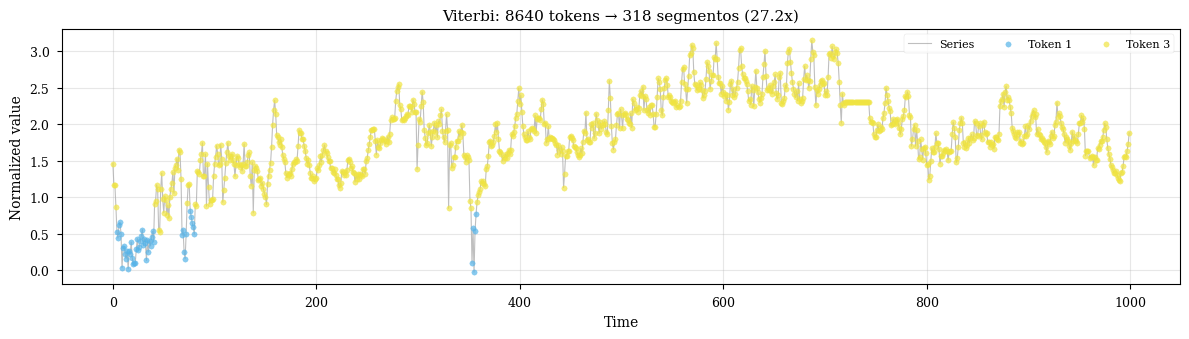


[GUARDADO] fase3_viterbi.pdf + .png


In [5]:
states, log_prob = viterbi_decode(data_train_norm, A, pi, mu, sigma)

state_changes = np.sum(states[1:] != states[:-1])
compression_ratio = len(data_train_norm) / (state_changes + 1)

print('[VITERBI TOKENIZACIÓN]')
print(f'  Vocabulario: K={K} tokens')
print(f'  Secuencia: T={len(states)} tokens (1 por timestep)')
print(f'  Segmentos: {state_changes+1} (run-length)')
print(f'  Ratio compresión: {compression_ratio:.2f}x')
print(f'  Log-probabilidad: {log_prob:.2f}')
print(f'\n  Distribución tokens:')
for k in range(K):
    count = np.sum(states == k)
    pct = 100 * count / len(states)
    print(f'    Token {k}: {count:4d} ({pct:5.2f}%)')

# VIZ: Segmentación temporal
fig, ax = plt.subplots(figsize=(12, 3.5))
t_viz = 1000

# Serie de fondo
ax.plot(data_train_norm[:t_viz], color='gray', linewidth=0.8, alpha=0.5, label='Series', zorder=1)

# Tokens coloreados
for k in range(K):
    mask = states[:t_viz] == k
    if np.any(mask):
        ax.scatter(np.where(mask)[0], data_train_norm[:t_viz][mask],
                  color=colors_oi[k], s=15, alpha=0.7, label=f'Token {k}', zorder=2)

ax.set_xlabel('Time')
ax.set_ylabel('Normalized value')
ax.set_title(f'Viterbi: {len(states)} tokens → {state_changes+1} segmentos ({compression_ratio:.1f}x)')
ax.legend(loc='upper right', fontsize=8, ncol=3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('notebooks/fase3_viterbi.pdf')
plt.savefig('notebooks/fase3_viterbi.png', dpi=300)
plt.show()
print('\n[GUARDADO] fase3_viterbi.pdf + .png')

## 5. Embeddings Estructurados

[EMBEDDINGS ESTRUCTURADOS]
  e_k = [μ_k, σ_k, A[k,:]]
  K=5 tokens → 5 embeddings
  Dimensión cruda: 7 = 2 + K
  d_model (proyectado): 128

  Ejemplo token 0:
    μ_0=-1.160, σ_0=0.249
    A[0,:]=[0.976 0.000 0.024 0.000 0.000]


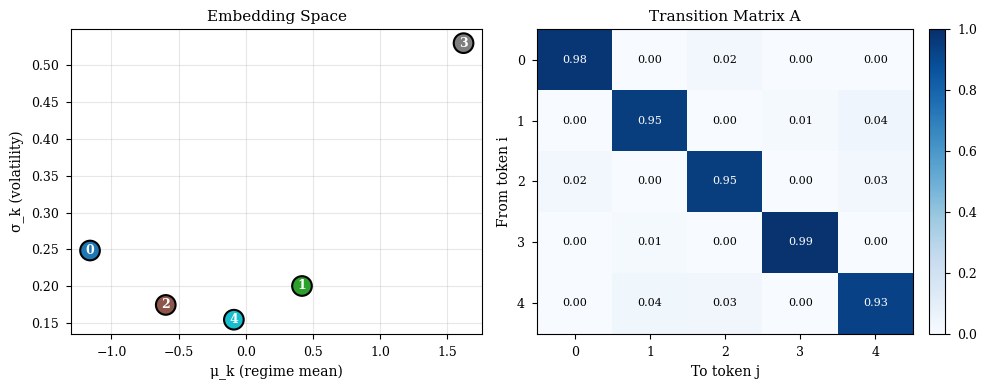


[GUARDADO] fase4_embeddings.pdf + .png


In [6]:
hmm_params_dict = {'A': A, 'mu': mu, 'sigma': sigma, 'pi': pi}
emb_gen = EmbeddingGenerator(hmm_params_dict, d_model=128, device='cpu')
embedding_table = emb_gen.get_embedding_table().numpy()

print('[EMBEDDINGS ESTRUCTURADOS]')
print(f'  e_k = [μ_k, σ_k, A[k,:]]')
print(f'  K={K} tokens → {K} embeddings')
print(f'  Dimensión cruda: {embedding_table.shape[1]} = 2 + K')
print(f'  d_model (proyectado): {emb_gen.d_model}')
print(f'\n  Ejemplo token 0:')
print(f'    μ_0={mu[0]:.3f}, σ_0={sigma[0]:.3f}')
print(f'    A[0,:]=[{" ".join(f"{x:.3f}" for x in A[0,:])}]')

# VIZ: Espacio embeddings + Matriz transición
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Panel A: μ vs σ
ax1.scatter(mu, sigma, c=range(K), cmap='tab10', s=200, edgecolors='black', linewidths=1.5, zorder=3)
for k in range(K):
    ax1.annotate(f'{k}', (mu[k], sigma[k]), ha='center', va='center',
                fontsize=9, fontweight='bold', color='white', zorder=4)
ax1.set_xlabel('μ_k (regime mean)')
ax1.set_ylabel('σ_k (volatility)')
ax1.set_title('Embedding Space')
ax1.grid(alpha=0.3)

# Panel B: Matriz A
im = ax2.imshow(A, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax2.set_xlabel('To token j')
ax2.set_ylabel('From token i')
ax2.set_title('Transition Matrix A')
ax2.set_xticks(range(K))
ax2.set_yticks(range(K))
for i in range(K):
    for j in range(K):
        ax2.text(j, i, f'{A[i,j]:.2f}', ha='center', va='center',
                color='white' if A[i,j] > 0.5 else 'black', fontsize=8)
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('notebooks/fase4_embeddings.pdf')
plt.savefig('notebooks/fase4_embeddings.png', dpi=300)
plt.show()
print('\n[GUARDADO] fase4_embeddings.pdf + .png')